In [2]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/150.0 MB 1.8 MB/s eta 0:01:25
   ---------------------------------------- 1.0/150.0 MB 1.8 MB/s eta 0:01:23
   ---------------------------------------- 1.6/150.0 MB 1.9 MB/s eta 0:01:18
    --------------------------------------- 2.1/150.0 MB 1.9 MB/s eta 0:01:17
    --------------------------------------- 2.6/150.0 MB 2.0 MB/s eta 0:01:15
    --------------------------------------- 2.9/150.0 MB 2.0 MB/s eta 0:01:16
    --------------------------------------- 3.4/150.0 MB 2.0 MB/s eta 0:01:13
   - -------------------------------------- 4.2/150.0 MB 1.9 MB/s eta 0:01:16
   - -------------------------------------- 4.5/150.0 MB 1.9 MB/s eta 0:01:16
   - -------------------------------------- 5.0/150.0 MB 1.9 MB/s eta 0:01:16
   - -------------------------------------- 5.2/150.0 MB 1.9 MB/s eta 0:01:17


In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.

In [3]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/CARRO_CLIENTES.csv", delimiter=',')

df.head(10)

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
5,846,Female,47,33500,1
6,219,Female,46,132500,1
7,588,Male,42,64000,0
8,85,Female,30,84500,0
9,465,Male,41,52000,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [7]:
df.isnull().values.any() 

False

In [8]:
df.drop(columns=['User ID'], inplace=True)

In [10]:
# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [13]:
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

In [15]:
df.drop(columns=['Gender'], inplace=True)

In [16]:
df.head(10)

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
5,47,33500,1,0
6,46,132500,1,0
7,42,64000,0,1
8,30,84500,0,0
9,41,52000,0,1


In [17]:
# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

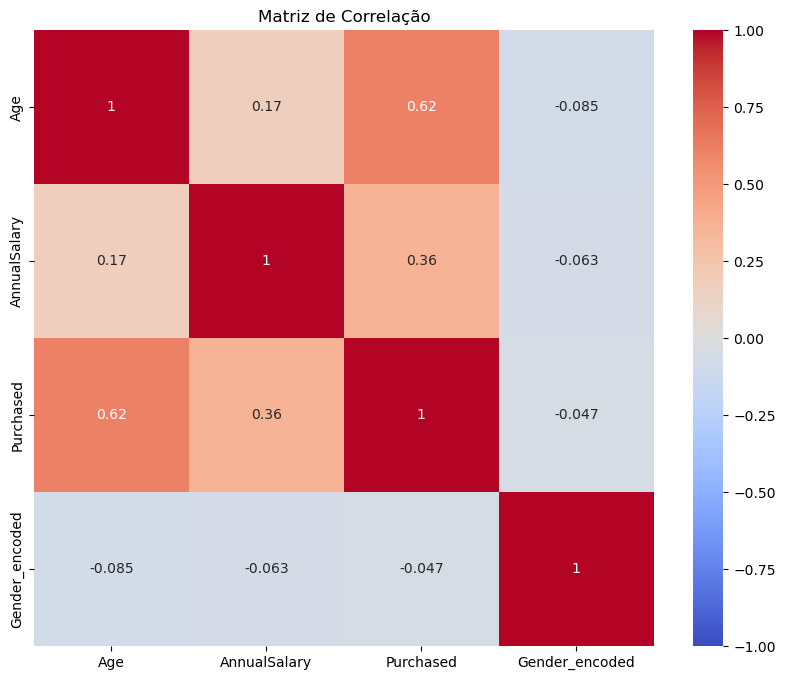

In [18]:
correlation_matrix = df.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [19]:
# As variaveis com maior correlação sao 'Age' e 'AnnualSalary'

In [20]:
# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [27]:
X = df.drop(columns=['Purchased'])
Y = df['Purchased']

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
# 5. Treino o modelo Xgboost com sua base de treino.
# Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [29]:
model_xgboost = xgb.XGBClassifier()
model_xgboost.objective

'binary:logistic'

In [30]:
model_xgboost = xgb.XGBClassifier().fit(X_train, Y_train)
model_xgboost.objective

'binary:logistic'

In [31]:
model_xgboost_hyper = xgb.XGBClassifier(
    max_depth=6,                  # Profundidade máxima da árvore
    n_estimators=100,             # Número de árvores a serem construídas

)

In [32]:
model_xgboost_hyper = xgb.XGBClassifier().fit(X_train, Y_train)

In [33]:
Y_pred = model_xgboost.predict(X_test)           # Previsões das classes
Y_pred_prob = model_xgboost.predict_proba(X_test)  # Probabilidades de cada classe

In [23]:
# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [34]:
Y_pred_prob

array([[9.1829747e-01, 8.1702508e-02],
       [1.8465167e-01, 8.1534833e-01],
       [9.9985957e-01, 1.4041355e-04],
       [8.8021886e-01, 1.1978113e-01],
       [2.3010248e-01, 7.6989752e-01],
       [5.1953197e-03, 9.9480468e-01],
       [3.1971931e-04, 9.9968028e-01],
       [9.9978024e-01, 2.1973831e-04],
       [9.9881536e-01, 1.1846230e-03],
       [9.9859673e-01, 1.4032825e-03],
       [9.9135143e-01, 8.6485716e-03],
       [9.9985874e-01, 1.4125205e-04],
       [9.1076910e-01, 8.9230925e-02],
       [9.9949300e-01, 5.0701422e-04],
       [1.4976263e-03, 9.9850237e-01],
       [3.6849558e-02, 9.6315044e-01],
       [7.1304142e-01, 2.8695861e-01],
       [1.0337609e-01, 8.9662391e-01],
       [9.3979836e-03, 9.9060202e-01],
       [9.9961460e-01, 3.8542028e-04],
       [9.9948639e-01, 5.1359483e-04],
       [1.5309453e-03, 9.9846905e-01],
       [2.0028949e-03, 9.9799711e-01],
       [9.9987763e-01, 1.2236778e-04],
       [7.3005557e-03, 9.9269944e-01],
       [9.7401077e-01, 2.

In [ ]:
# por exemplo: na primeira linha vemos que a probabilidade 9.1829747e-01 representa que aproximadamente 91,19% de probabilidade da amostra
# pertencer à primeira classe (classe 0) e 8.1702508e-02 representa que existe 81,70 de probabilidade de pertencer à classe segunda classe (classe 1)

In [24]:
# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [35]:
# Então uma vez que temos as probabilidades, fazemos a transformação das previsões e os rótulos de volta para os rótulos originais
Y_pred_original = label_encoder.inverse_transform(Y_pred)
Y_test_original = label_encoder.inverse_transform(Y_test)

In [36]:
accuracy = accuracy_score(Y_test_original, Y_pred_original)
report = classification_report(Y_test_original, Y_pred_original)
conf_matrix = confusion_matrix(Y_test_original, Y_pred_original)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.9
Relatório de Classificação:
              precision    recall  f1-score   support

      Female       0.90      0.93      0.91       112
        Male       0.90      0.86      0.88        88

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200

Matriz de Confusão:
[[104   8]
 [ 12  76]]


In [38]:
# Modelo altamente satisfaótio! precisao em 90%, assim como a acurácia. recall e f1-score tambem em otimos resultados e
# matriz de confusao demonstrando alto indice de acertos de verdadeiros positivos e falsos negativos 

In [25]:
# 8. Traga a lista com a feature importance.
# As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [37]:
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

          Feature  Importance
0             Age    1.789283
1    AnnualSalary    1.068870
2  Gender_encoded    0.461889
